# Notebook 02 — xarray + Dask Loading

**What you will learn:**
- How `odc-stac` turns STAC Items into a labelled `xarray.Dataset`
- What xarray's `dims`, `coords`, and `data_vars` each mean
- What lazy loading is and why it matters
- How Dask represents deferred computation as a task graph

---

## Background: xarray in one paragraph

NumPy arrays are indexed by integer position. xarray wraps arrays with **labelled dimensions** (`time`, `y`, `x`) and **coordinates** (actual datetime values, UTM metre positions). This means you can select by value (`ds.sel(time='2023-07-15')`) instead of by position (`ds[:, 3, :]`). A `Dataset` holds multiple named arrays (called **data variables**) that share the same dimensions.

## Background: Dask in one paragraph

Dask lets xarray hold a *description of how to compute an array* rather than the array itself. No data is read from S3 until you explicitly call `.compute()` or plot. This is called **lazy evaluation**. Dask tracks the pending operations as a directed acyclic graph of tasks — you can visualise this graph to understand exactly what work will happen when you trigger computation.

In [1]:
import sys
sys.path.insert(0, "..")

import xarray as xr
import odc.stac
import dask
from dask.distributed import Client
from utils.stac_helpers import search_sentinel2

# Start a local Dask cluster with 2 workers.
# The dashboard at the printed URL lets you watch tasks execute in real time.
client = Client(n_workers=2, threads_per_worker=2, memory_limit="2GB")
print("Dask dashboard:", client.dashboard_link)

Dask dashboard: http://127.0.0.1:8787/status


## Load STAC items into an xarray Dataset

`odc.stac.load()` does several things in one call:
1. Reads the COG headers (tiny HTTP requests) to discover each file's CRS, transform, and dimensions
2. Aligns all scenes to a common grid in the requested CRS and resolution
3. Returns a **lazy** xarray Dataset — no pixel data is fetched yet

In [2]:
from utils.stac_helpers import DEFAULT_BBOX

items = search_sentinel2()
print(f"Loaded {len(items)} STAC items")

# odc.stac.load: bands uses the asset key names from earth-search
# resolution=20 means 20-metre pixels (native Sentinel-2 resolution for these bands)
# bbox clips the output to the search area — without it odc-stac loads the full
# extent of every matching Sentinel-2 tile, which covers a much larger region.
ds = odc.stac.load(
    items,
    bands=["blue", "green", "red", "nir"],
    crs="EPSG:32618",   # UTM Zone 18N — covers Southeastern PA
    resolution=20,
    bbox=DEFAULT_BBOX,  # [lon_min, lat_min, lon_max, lat_max] WGS84
    chunks={"time": 1, "y": 2048, "x": 2048},  # Dask chunk sizes
)

# odc-stac stores the CRS in a 'spatial_ref' scalar coordinate, but rasterio
# expects it encoded as a standard geotransform. write_crs() bridges the two.
import rioxarray  # noqa — registers the .rio accessor
ds = ds.rio.write_crs("EPSG:32618")

print(ds)

Loaded 3 STAC items
<xarray.Dataset> Size: 144MB
Dimensions:      (y: 2788, x: 2158, time: 3)
Coordinates:
  * y            (y) float64 22kB 4.428e+06 4.428e+06 ... 4.372e+06 4.372e+06
  * x            (x) float64 17kB 4.355e+05 4.355e+05 ... 4.786e+05 4.786e+05
  * time         (time) datetime64[ns] 24B 2023-06-04T16:02:09.577000 ... 202...
    spatial_ref  int64 8B 0
Data variables:
    blue         (time, y, x) uint16 36MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    green        (time, y, x) uint16 36MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    red          (time, y, x) uint16 36MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    nir          (time, y, x) uint16 36MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>


## Anatomy of an xarray Dataset

The repr above shows three categories:

- **Dimensions** (`dims`): the named axes — `time`, `y`, `x`. Every variable must be defined over a subset of these.
- **Coordinates** (`coords`): the actual label values along each axis — datetime objects for `time`, UTM metre values for `y`/`x`.
- **Data variables** (`data_vars`): the actual data arrays — one per band (`blue`, `green`, `red`, `nir`).

In [3]:
print("=== Dimensions ===")
print(dict(ds.sizes))

print("\n=== Coordinates ===")
for name, coord in ds.coords.items():
    if coord.ndim > 0:
        print(f"  {name}: {coord.values[:3]} ...")
    else:
        print(f"  {name}: {coord.values} (scalar)")

print("\n=== Data variables ===")
for name, var in ds.data_vars.items():
    print(f"  {name}: dtype={var.dtype}  shape={var.shape}")

print("\n=== Chunk sizes ===")
print(ds.chunks)

=== Dimensions ===
{'y': 2788, 'x': 2158, 'time': 3}

=== Coordinates ===
  y: [4428030. 4428010. 4427990.] ...
  x: [435510. 435530. 435550.] ...
  time: ['2023-06-04T16:02:09.577000000' '2023-06-04T16:02:23.872000000'
 '2023-08-13T16:02:25.315000000'] ...
  spatial_ref: 0 (scalar)

=== Data variables ===
  blue: dtype=uint16  shape=(3, 2788, 2158)
  green: dtype=uint16  shape=(3, 2788, 2158)
  red: dtype=uint16  shape=(3, 2788, 2158)
  nir: dtype=uint16  shape=(3, 2788, 2158)

=== Chunk sizes ===
Frozen({'time': (1, 1, 1), 'y': (2048, 740), 'x': (2048, 110)})


## Lazy arrays: the data has NOT been read yet

Each data variable holds a **Dask array** — a graph of future operations, not actual pixel values. Printing it shows its shape and dtype but does not trigger any S3 reads.

In [4]:
import dask.array as da

red_array = ds["red"].data
print(type(red_array))         # dask.array.Array
print(red_array)               # shape, dtype, chunk layout — but no values
print()
print("Is it a Dask array?", isinstance(red_array, da.Array))  # True
print("Number of chunks:  ", red_array.npartitions)

<class 'dask.array.core.Array'>
dask.array<red, shape=(3, 2788, 2158), dtype=uint16, chunksize=(1, 2048, 2048), chunktype=numpy.ndarray>

Is it a Dask array? True
Number of chunks:   12


## Select and plot one scene

`isel(time=0)` selects the first time step by **integer position** (like NumPy indexing). This returns a 2-D DataArray — still lazy until plotted or computed.

Scene date: 2023-06-04T16:02:09.577000000


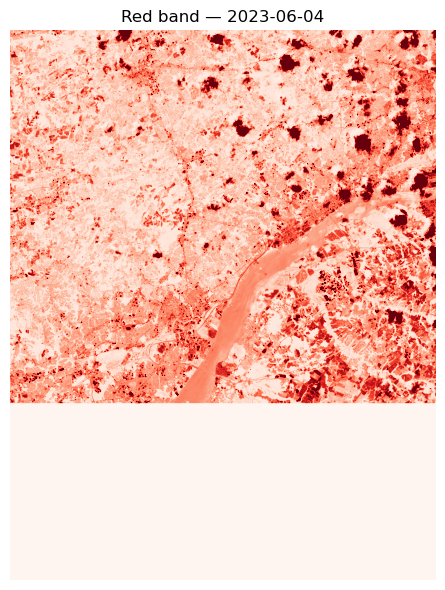

In [5]:
import matplotlib.pyplot as plt
import numpy as np

scene0 = ds.isel(time=0)  # 2-D Dataset: y × x
print("Scene date:", scene0.time.values)

# .values triggers .compute() implicitly — Dask fetches the data here
red_vals = scene0["red"].values

fig, ax = plt.subplots(figsize=(8, 6))
# Clip to 2nd–98th percentile to avoid stretching on extreme values
vmin, vmax = np.nanpercentile(red_vals, [2, 98])
ax.imshow(red_vals, cmap="Reds", vmin=vmin, vmax=vmax, origin="upper")
ax.set_title(f"Red band — {str(scene0.time.values)[:10]}")
ax.axis("off")
plt.tight_layout()
plt.show()

## Explicit .compute() and memory

Calling `.compute()` on a Dask-backed DataArray forces all pending tasks to execute and returns a regular NumPy-backed DataArray. After this call the data lives in RAM.

In [6]:
import tracemalloc, warnings
import rasterio

warnings.filterwarnings("ignore", category=rasterio.errors.NotGeoreferencedWarning)

tracemalloc.start()
before = tracemalloc.get_traced_memory()[0]

red_computed = ds["red"].isel(time=0).compute()

after = tracemalloc.get_traced_memory()[0]
tracemalloc.stop()

print(f"Memory used by compute(): {(after - before) / 1e6:.1f} MB")
print(f"Underlying array type:    {type(red_computed.data)}")
print(f"Is still Dask?            {isinstance(red_computed.data, da.Array)}")

Memory used by compute(): 12.4 MB
Underlying array type:    <class 'numpy.ndarray'>
Is still Dask?            False


## Visualise the Dask task graph

The task graph shows every operation Dask will perform to materialise one chunk. Reading from S3 is at the leaf nodes; array operations (type conversion, etc.) are the inner nodes. This requires `graphviz` to be installed.

In [7]:
import os
os.makedirs("../data", exist_ok=True)

try:
    # Show the graph for just one time slice to keep it readable
    graph = ds["red"].isel(time=0).data
    graph.visualize(filename="../data/task_graph.png", rankdir="LR")
    from IPython.display import Image
    display(Image("../data/task_graph.png"))
    print("Task graph saved to data/task_graph.png")
except Exception as e:
    print(f"graphviz not available ({e}) — skipping visualisation")
    print(f"Task graph has {len(ds['red'].isel(time=0).data.__dask_graph__())} nodes")

graphviz not available (No visualization engine detected, please install graphviz or ipycytoscape) — skipping visualisation
Task graph has 21 nodes


## Verify CRS with rioxarray

`odc.stac.load` sets the CRS in xarray attributes. rioxarray's `.rio` accessor can read it back.

In [8]:
print("CRS:", ds.rio.crs)
print("EPSG:", ds.rio.crs.to_epsg() if ds.rio.crs else "not set")

CRS: EPSG:32618
EPSG: 32618


## Save the Dataset for later notebooks

We compute and persist the Dataset to local Zarr so notebooks 03–07 don't need to re-download from S3.

In [9]:
import os, time, warnings
import rasterio

# Suppress rasterio's NotGeoreferencedWarning globally — it fires inside Dask
# worker threads where catch_warnings() context managers have no effect.
warnings.filterwarnings("ignore", category=rasterio.errors.NotGeoreferencedWarning)

zarr_path = "../data/sentinel2_local.zarr"

print("Computing and writing to Zarr (this fetches data from S3)...")
t0 = time.perf_counter()
ds.to_zarr(zarr_path, mode="w")
t1 = time.perf_counter()
print(f"Written to {zarr_path}  ({t1 - t0:.1f}s)")
print(f"Directory size: {sum(os.path.getsize(os.path.join(dp, f)) for dp, dn, fn in os.walk(zarr_path) for f in fn) / 1e6:.1f} MB")

Computing and writing to Zarr (this fetches data from S3)...
Written to ../data/sentinel2_local.zarr  (65.2s)
Directory size: 66.6 MB


## Validation

In [10]:
assert isinstance(ds["red"].data, da.Array), "red band should be Dask-backed"
assert set(ds.data_vars) == {"blue", "green", "red", "nir"}, "Missing bands"
assert "time" in ds.sizes and "y" in ds.sizes and "x" in ds.sizes, "Missing dimensions"
assert ds.sizes["time"] >= 2, "Expected at least 2 time steps"
assert os.path.isdir(zarr_path), "Zarr store not written"
print("All assertions passed.")

All assertions passed.


---
## Learning Checkpoint — Q&A

**Q1:** What does "lazy loading" mean? At what point does data actually transfer from the COG URL to memory?

> *Lazy loading means the array stores a recipe (a Dask task graph) rather than actual values. Data is only fetched when `.compute()` is called, or implicitly when you access `.values`, plot, or write to Zarr.*

**Q2:** What do `.dims`, `.coords`, and `.data_vars` each represent?

> *`.dims` are the named axis sizes (e.g. `time=3, y=2500, x=2500`). `.coords` are the label values along each axis (actual datetimes, UTM metre values). `.data_vars` are the named arrays containing the actual data (one per band).*

**Q3:** What is a Dask task graph and why is it useful to inspect one?

> *A task graph is a DAG where each node is a computation step and edges are data dependencies. Inspecting it reveals how many S3 reads will occur, how operations are parallelised, and where bottlenecks may be — before you commit to executing anything.*

**Q4:** What happens to memory when you call `.compute()`? What's the tradeoff?

> *The Dask array is replaced by a NumPy array held in RAM. The tradeoff: you gain fast, random access to pixel values, but you consume memory proportional to the array size. For large time series this can exceed available RAM — which is why staying lazy until necessary matters.*